In [85]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm, trange

In [86]:
%matplotlib inline

In [87]:
train_n = 100
test_n = 1000
d = 100

In [88]:
def generate_data():
    X_train = np.random.normal(0,1, size=(train_n,d))
    w_true = np.random.normal(0,1, size=(d,1))
    y_train = X_train.dot(w_true) + np.random.normal(0,0.5,size=(train_n,1))
    X_test = np.random.normal(0,1, size=(test_n,d))
    y_test = X_test.dot(w_true) + np.random.normal(0,0.5,size=(test_n,1))
    return w_true, X_train, y_train, X_test, y_test

# 3.1

In [89]:
def normalized_error(X, y, w):
    resid = X @ w - y
    return float(np.linalg.norm(resid, 2) / np.linalg.norm(y, 2))

f_hat_train, f_hat_test = [], []
for t in range(10):
    w_true, X_train, y_train, X_test, y_test = generate_data()
    w_hat, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
    w_hat = w_hat.reshape(-1,1)

    f_hat_train.append(normalized_error(X_train, y_train, w_hat))
    f_hat_test.append(normalized_error(X_test, y_test, w_hat))

print(f"Normalized train error (linalg soln): {np.mean(f_hat_train):.5e}")
print(f"Normalized test error (linalg soln): {np.mean(f_hat_test):.5e}")

Normalized train error (linalg soln): 2.36650e-15
Normalized test error (linalg soln): 9.38908e-01


# 3.2

  0%|          | 0/10 [00:00<?, ?it/s]

Normalized train error (L2 linalg soln): [0.000694572678037903, 0.0021394315307958745, 0.005061066952175308, 0.016583481428664906, 0.07668737760001355, 0.31489865360553804, 0.7579298067887492]
Normalized test error (L2 linalg soln): [0.619658812274942, 0.36917058224995364, 0.2565816013964633, 0.23790005585230828, 0.3513977210046756, 0.5975721100210353, 0.8774123407972899]


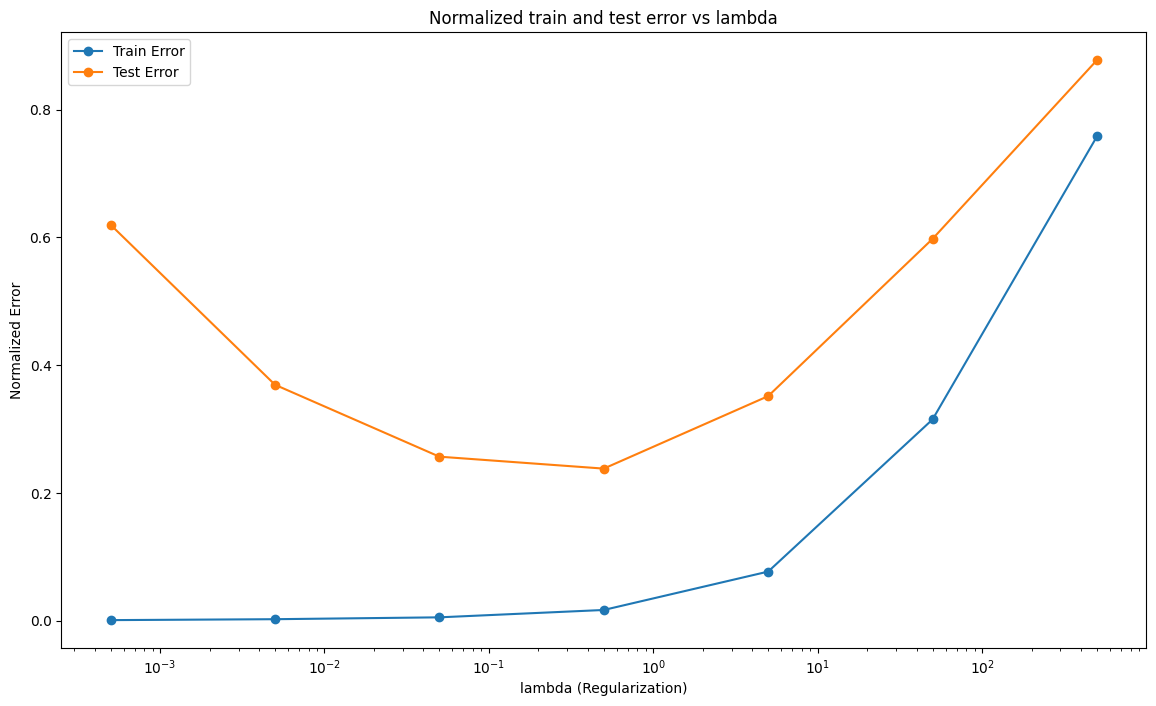

In [90]:
n_trials = 10
l_reg_list = [0.0005, 0.005, 0.05, 0.5, 5, 50, 500]
avg_f_hat_train_per_l, avg_f_hat_test_per_l = [0.0]* len(l_reg_list), [0.0]* len(l_reg_list)

for t in trange(n_trials):
    w_true, X_train, y_train, X_test, y_test = generate_data()

    for l_idx, l_reg in enumerate(l_reg_list):
        d = X_train.shape[1]
        A = X_train.T @ X_train
        reg = l_reg * np.eye(d)
        w_ridge = np.linalg.solve(A + reg, X_train.T @ y_train)  # shape (d,1)
        avg_f_hat_train_per_l[l_idx] += normalized_error(X_train, y_train, w_ridge)
        avg_f_hat_test_per_l[l_idx] += normalized_error(X_test, y_test, w_ridge)

avg_f_hat_train_per_l = [x / n_trials for x in avg_f_hat_train_per_l]
avg_f_hat_test_per_l = [x / n_trials for x in avg_f_hat_test_per_l]

fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='o', label='Train Error')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='o', label='Test Error')
axs.set_xscale('log')
axs.set_xlabel('lambda (Regularization)')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs lambda')
axs.legend()

print(f"Normalized train error (L2 linalg soln): {avg_f_hat_train_per_l}")
print(f"Normalized test error (L2 linalg soln): {avg_f_hat_test_per_l}")

# 3.3

In [91]:
def sgd(X, y, w, step_size, n_steps):
    n, d = X.shape
    # ensure copy so we don't modify caller's w accidentally
    w = w.copy()
    for _ in trange(n_steps):
        i = np.random.randint(0, n)
        x_i = X[i:i+1, :]  # shape (1,d)
        y_i = y[i:i+1, :]  # shape (1,1)
        w = w - step_size * (x_i.T @ (x_i @ w - y_i))
    return w

In [92]:
n_trials = 10
step_size_list = [5e-5, 5e-4, 5e-3]
avg_f_hat_train_per_ss, avg_f_hat_test_per_ss = [0.0]* len(step_size_list), [0.0]* len(step_size_list)

for t in trange(n_trials, desc="Trail #"):
    w_true, X_train, y_train, X_test, y_test = generate_data()

    for ss_idx, step_size in enumerate(step_size_list):
      # implement and update avg_f_hat_train_per_ss, avg_f_hat_test_per_ss
        d = X_train.shape[1]
        w_init = np.zeros((d,1))
        w_sgd = sgd(X_train, y_train, w_init, step_size, n_steps=1000)
        avg_f_hat_train_per_ss[ss_idx] += normalized_error(X_train, y_train, w_sgd)
        avg_f_hat_test_per_ss[ss_idx] += normalized_error(X_test, y_test, w_sgd)

avg_f_hat_train_per_ss = [x / n_trials for x in avg_f_hat_train_per_ss]
avg_f_hat_test_per_ss = [x / n_trials for x in avg_f_hat_test_per_ss]

print(f"Normalized train error (SGD): {avg_f_hat_train_per_ss}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_ss}")

Trail #:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Normalized train error (SGD): [0.9115244946131057, 0.4932474218193664, 0.1186903030379042]
Normalized test error (SGD): [0.9552768274206758, 0.7283767698937242, 0.39853901665732244]


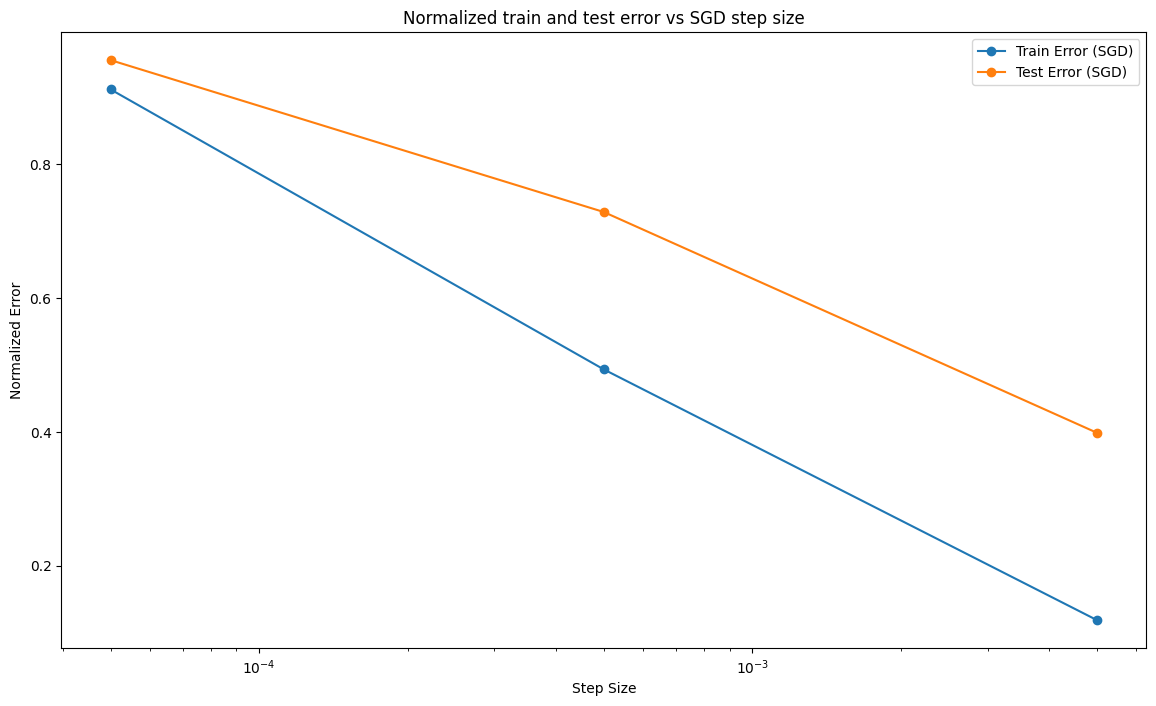

In [93]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(step_size_list, avg_f_hat_train_per_ss, marker='o', label='Train Error (SGD)')
axs.plot(step_size_list, avg_f_hat_test_per_ss, marker='o', label='Test Error (SGD)')
axs.set_xscale('log')
axs.set_xlabel('Step Size')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()

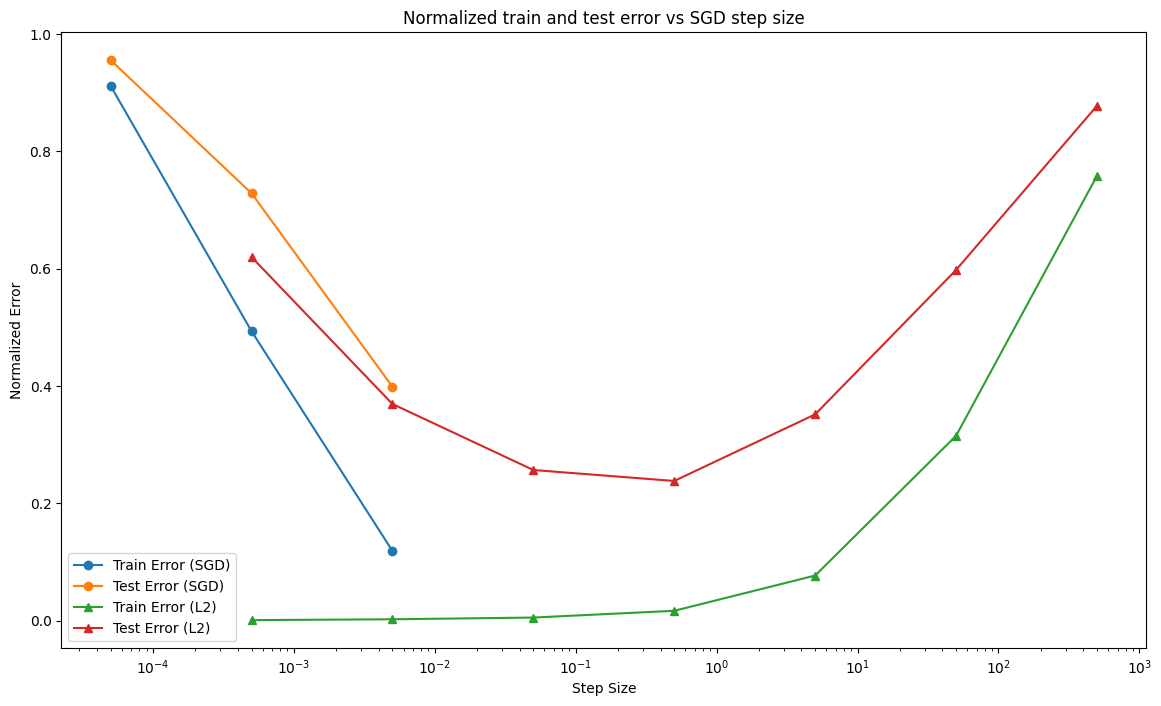

In [94]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(step_size_list, avg_f_hat_train_per_ss, marker='o', label='Train Error (SGD)')
axs.plot(step_size_list, avg_f_hat_test_per_ss, marker='o', label='Test Error (SGD)')
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='^', label='Train Error (L2)')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='^', label='Test Error (L2)')
axs.set_xscale('log')
axs.set_xlabel('Step Size')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()

# 3.4

In [95]:
def sgd_w_tracking(X, y, X_te, y_te, w, step_size, n_steps, eval_every=100):
    train_errs, test_errs, w_norms = [], [], []
    print(f"Step size: {step_size}")
    n, d = X.shape
    w = w.copy()
    for step_ctr in trange(n_steps, desc="SGD iteration"):
        i = np.random.randint(0, n)
        xi = X[i:i+1, :]    # shape (1,d)
        yi = y[i:i+1, :]    # shape (1,1)
        w = w - step_size * (xi.T @ (xi @ w - yi))
        if step_ctr % eval_every == 0:
            train_errs.append(normalized_error(X, y, w))
            test_errs.append(normalized_error(X_te, y_te, w))
            w_norms.append(np.linalg.norm(w, 2))

    return w, train_errs, test_errs, w_norms

In [96]:
step_size_list = [5e-5, 5e-3]
f_hat_train_trend_per_ss, f_hat_test_trend_per_ss, w_norm_trend = [None]* len(step_size_list), [None]* len(step_size_list), [None]* len(step_size_list)
f_hat_train_true, f_hat_test_true = [], []

w_true, X_train, y_train, X_test, y_test = generate_data()
f_hat_train_true = normalized_error(X_train, y_train, w_true)
f_hat_test_true = normalized_error(X_test, y_test, w_true)

for ss_idx, step_size in enumerate(step_size_list):
     # compute w_est, train_errors, test_errors, w_est_norms for each step size
    d = X_train.shape[1]
    w_init = np.zeros((d,1))
    print(f"Running SGD trace for step size = {step_size} ...")

    w_est, train_errors, test_errors, w_est_norms = sgd_w_tracking(X_train, y_train, X_test, y_test, w_init, step_size, n_steps=1000000, eval_every=100)


    f_hat_train_trend_per_ss[ss_idx] = train_errors
    f_hat_test_trend_per_ss[ss_idx] = test_errors
    w_norm_trend[ss_idx] = w_est_norms

Running SGD trace for step size = 5e-05 ...
Step size: 5e-05


SGD iteration:   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SGD trace for step size = 0.005 ...
Step size: 0.005


SGD iteration:   0%|          | 0/1000000 [00:00<?, ?it/s]

### 3.4 (i)

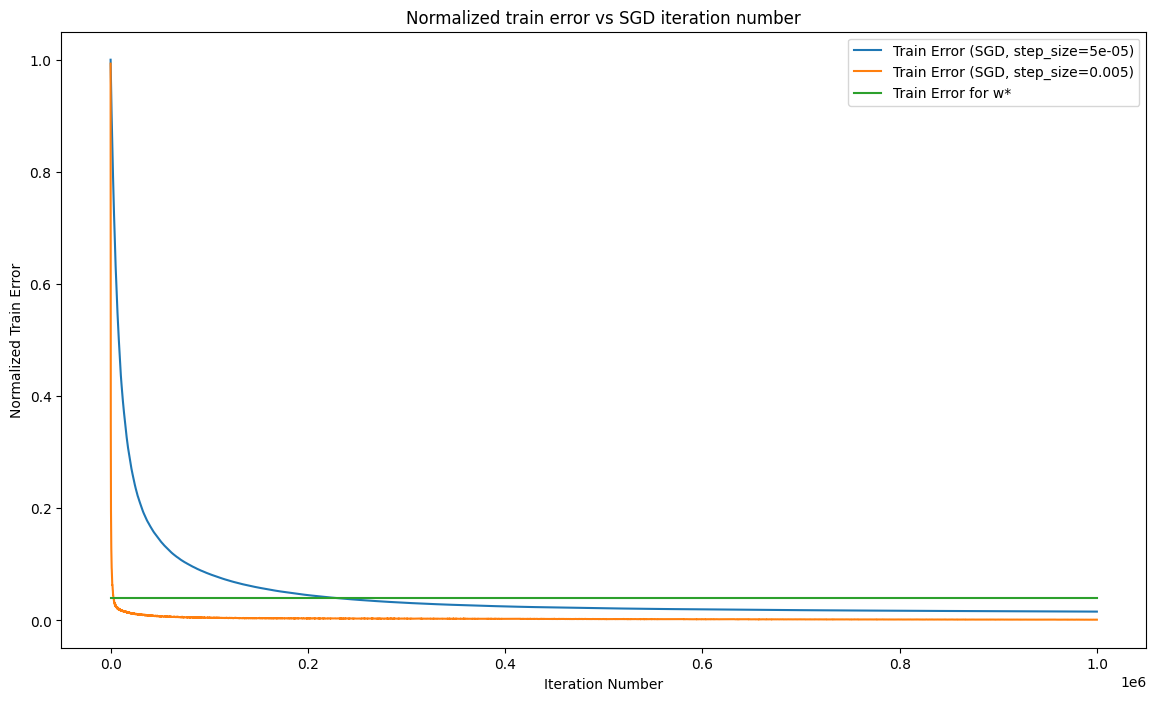

In [97]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(0, 1000000, 100), f_hat_train_trend_per_ss[ss_idx],
             label=f'Train Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_train_true, f_hat_train_true], label='Train Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Train Error')
axs.set_title('Normalized train error vs SGD iteration number')
axs.legend()

### 3.4 (ii)

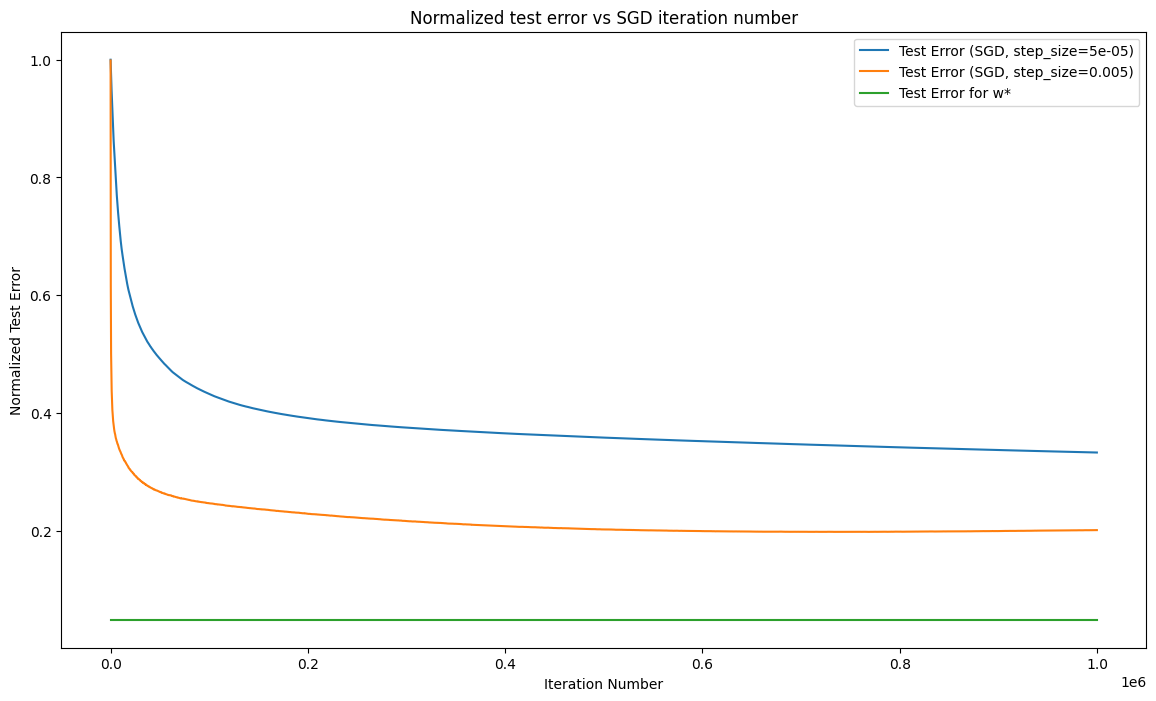

In [98]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(0, 1000000, 100), f_hat_test_trend_per_ss[ss_idx],
             label=f'Test Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_test_true, f_hat_test_true], label='Test Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Test Error')
axs.set_title('Normalized test error vs SGD iteration number')
axs.legend()

### 3.4 (iii)

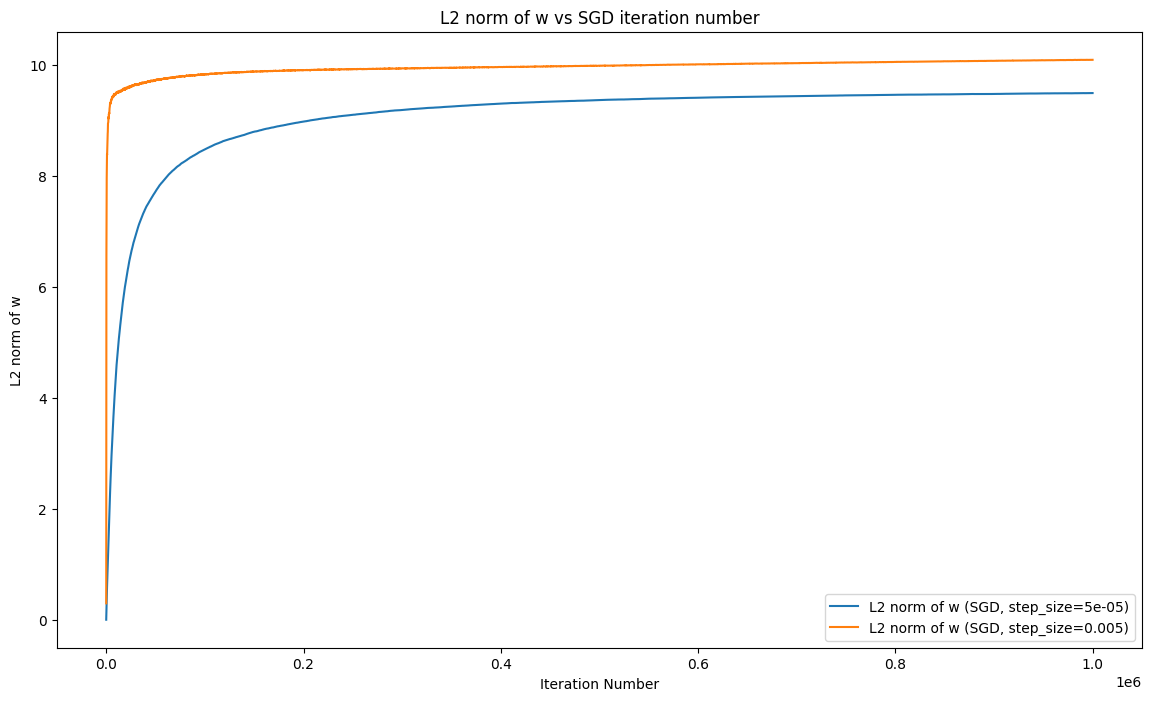

In [99]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(0, 1000000, 100), w_norm_trend[ss_idx],
             label=f'L2 norm of w (SGD, step_size={step_size})')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('L2 norm of w')
axs.set_title('L2 norm of w vs SGD iteration number')
axs.legend()

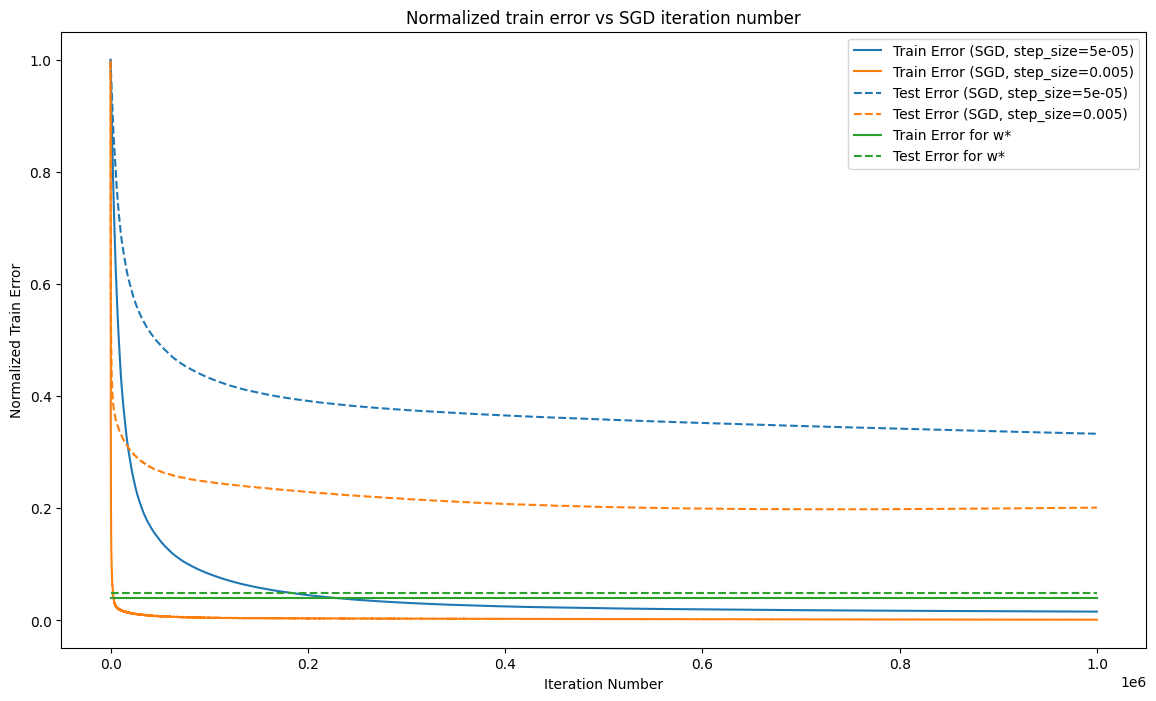

In [100]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(0, 1000000, 100), f_hat_train_trend_per_ss[ss_idx], f'C{ss_idx}',
             label=f'Train Error (SGD, step_size={step_size})')

for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(0, 1000000, 100), f_hat_test_trend_per_ss[ss_idx], f'C{ss_idx}--',
             label=f'Test Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_train_true, f_hat_train_true], 'C2', label='Train Error for w*')
axs.plot([0, 1000000], [f_hat_test_true, f_hat_test_true], 'C2--', label='Test Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Train Error')
axs.set_title('Normalized train error vs SGD iteration number')
axs.legend()

# 3.5

In [101]:
n_trials = 10
r_list = [0, 0.1, 0.5, 1, 10, 20, 30]
avg_f_hat_train_per_r, avg_f_hat_test_per_r, w_norm_per_r = [0.0]* len(r_list), [0.0]* len(r_list), [0.0]* len(r_list)

for t in trange(n_trials, desc="Trail #"):
    # implement and update avg_f_hat_train_per_r, avg_f_hat_test_per_r, w_norm_per_r
    w_true, X_train, y_train, X_test, y_test = generate_data()
    d = X_train.shape[1]
    for r_idx, r in enumerate(r_list):
        if r == 0:
            w_init = np.zeros((d,1))
        else:
            w_init = np.random.normal(0, r, size=(d,1))
            norm_w = float(np.linalg.norm(w_init, 2))
            if norm_w == 0:
              w_init = np.zeros((d,1))
            else:
              w_init = w_init / norm_w * r

        w_final = sgd(X_train, y_train, w_init, step_size=5e-5, n_steps=1_000_000)
        train_err = normalized_error(X_train, y_train, w_final)
        test_err = normalized_error(X_test, y_test, w_final)
        w_norm = float(np.linalg.norm(w_final, 2))
        avg_f_hat_train_per_r[r_idx] += train_err
        avg_f_hat_test_per_r[r_idx] += test_err
        w_norm_per_r[r_idx] += w_norm

avg_f_hat_train_per_r = [x / n_trials for x in avg_f_hat_train_per_r]
avg_f_hat_test_per_r = [x / n_trials for x in avg_f_hat_test_per_r]
w_norm_per_r = [x / n_trials for x in w_norm_per_r]

print(f"Normalized train error (SGD): {avg_f_hat_train_per_r}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_r}")

Trail #:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

Normalized train error (SGD): [0.01844811736037696, 0.01844619254153271, 0.01836896465702038, 0.018839201020431552, 0.026063121411726252, 0.03512519074785557, 0.05235443608052459]
Normalized test error (SGD): [0.28168725322297444, 0.2815535103381965, 0.27949234471665874, 0.2847776107653084, 0.41102107877794386, 0.47799164140110106, 0.7404279809961055]


Normalized train error (SGD): [0.01844811736037696, 0.01844619254153271, 0.01836896465702038, 0.018839201020431552, 0.026063121411726252, 0.03512519074785557, 0.05235443608052459]
Normalized test error (SGD): [0.28168725322297444, 0.2815535103381965, 0.27949234471665874, 0.2847776107653084, 0.41102107877794386, 0.47799164140110106, 0.7404279809961055]


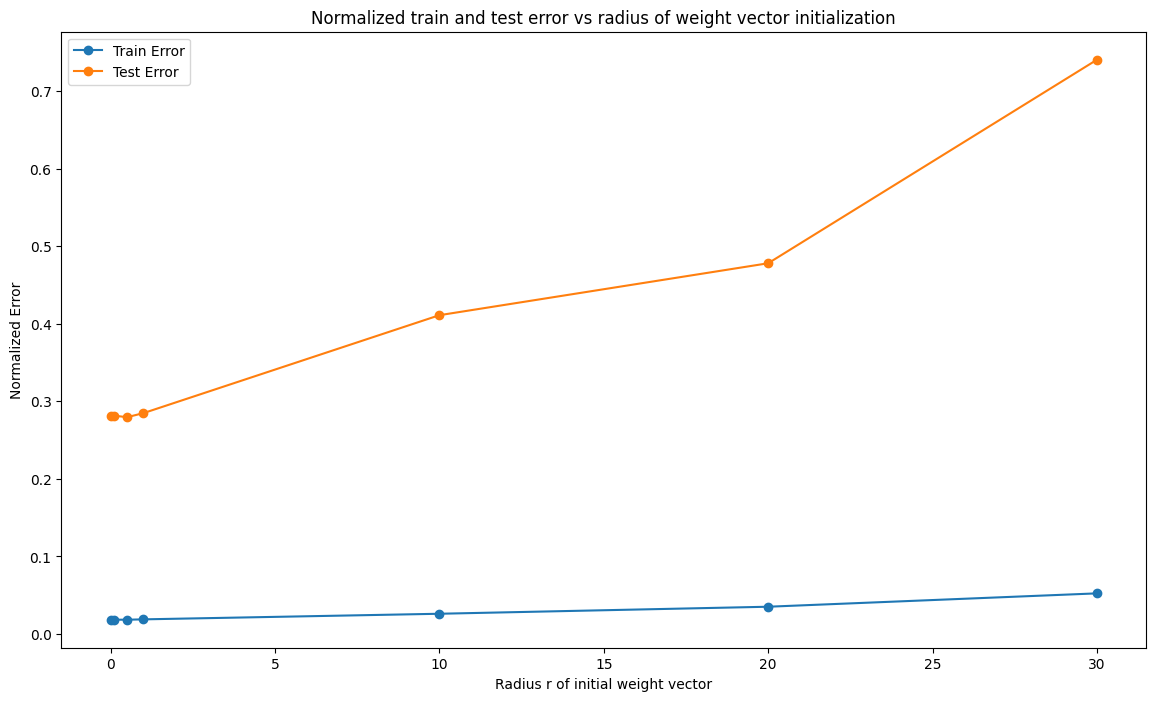

In [102]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(r_list, avg_f_hat_train_per_r, marker='o', label='Train Error')
axs.plot(r_list, avg_f_hat_test_per_r, marker='o', label='Test Error')

axs.set_xlabel('Radius r of initial weight vector')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs radius of weight vector initialization')
axs.legend()

print(f"Normalized train error (SGD): {avg_f_hat_train_per_r}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_r}")

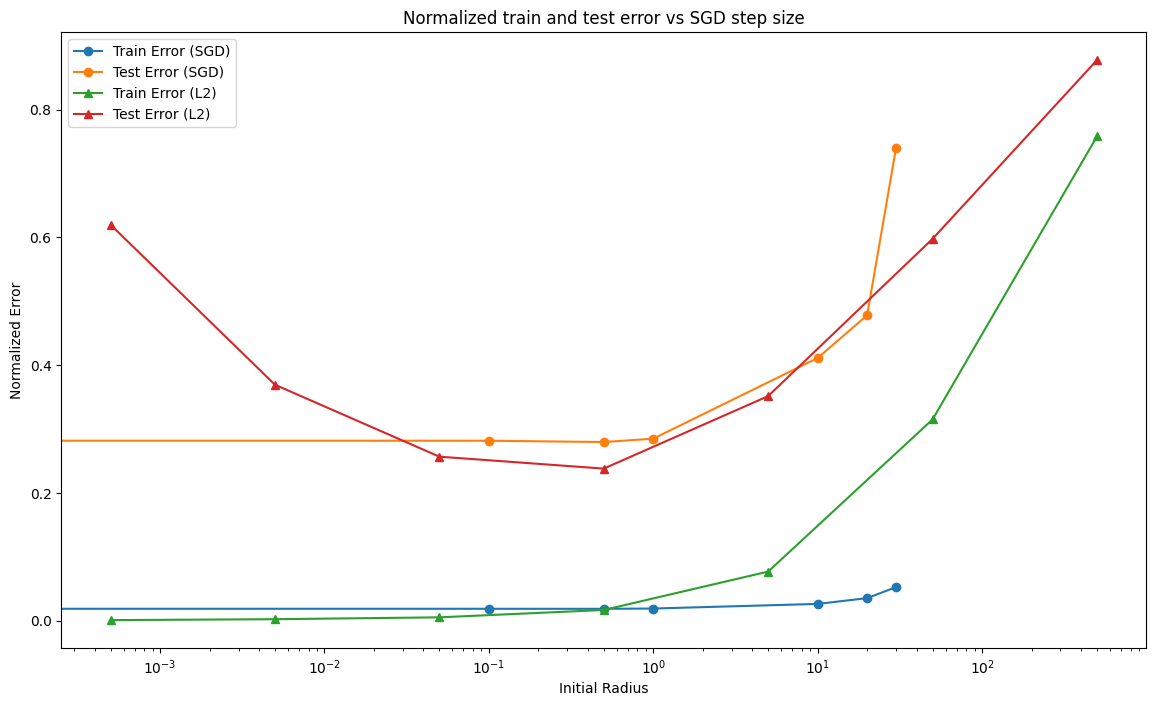

In [103]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(r_list, avg_f_hat_train_per_r, marker='o', label='Train Error (SGD)')
axs.plot(r_list, avg_f_hat_test_per_r, marker='o', label='Test Error (SGD)')
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='^', label='Train Error (L2)')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='^', label='Test Error (L2)')
axs.set_xscale('log')
axs.set_xlabel('Initial Radius')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()